Create risk register dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create Risk Register dataset
data = {
    "Risk ID": ["R1","R2","R3","R4","R5","R6","R7","R8","R9","R10",
                "R11","R12","R13","R14","R15","R16","R17","R18","R19","R20",
                "R21","R22","R23","R24","R25","R26","R27","R28","R29","R30"],
    "Risk Name": [
        "Competitive AI Disruption",
        "Customer Migration Risk",
        "AI-Driven Supply Chain Optimization and Cost Leadership Risk",
        "ROI realization failure",
        "AI Implementation Cost Overrun",
        "Revenue Loss from AI Service Disruptions",
        "Inventory Loss from AI Forecast Errors",
        "Expected Labor Cost Reduction Not Achieved",
        "Inventory Forecast Error",
        "Stockout Risk",
        "Overstock Risk",
        "Replenishment Delay",
        "Fulfillment Disruption",
        "Incorrect Workforce Scheduling",
        "Productivity Decline During Transition",
        "Poor Data Quality",
        "Operational Decision Errors",
        "Excessive Dependence on Automation",
        "Customer Trust Erosion",
        "Negative Public Perception of AI",
        "AI-Related Customer Complaints",
        "Brand Damage from AI Failures",
        "AI Recommendation Inaccuracy",
        "AI Model Drift",
        "System Downtime",
        "Legacy System Integration Failure",
        "Vendor Dependency",
        "Customer Data Breach",
        "Regulatory Non-Compliance",
        "Algorithmic Bias & Ethical AI Issues"
    ],
    "Likelihood": [3,5,5,5,7,5,7,5,7,7,5,5,7,5,7,7,5,5,5,5,7,3,5,7,5,7,7,5,5,3],
    "Impact": [8,6,4,8,2,6,4,1,8,8,6,6,8,4,2,4,4,6,6,4,2,8,4,2,8,6,6,8,6,4]
}

df = pd.DataFrame(data)
df["Risk Score"] = df["Likelihood"] * df["Impact"]

df["Priority"] = df["Risk Score"].apply(
    lambda x: "H" if x >= 40 else ("M" if x >= 15 else "L")
)

df

,Risk ID,Risk Name,Likelihood,Impact,Risk Score,Priority
0,R1,Competitive AI Disruption,3,8,24,M
1,R2,Customer Migration Risk,5,6,30,M
2,R3,AI-Driven Supply Chain Optimization and Cost L...,5,4,20,M
3,R4,ROI realization failure,5,8,40,H
4,R5,AI Implementation Cost Overrun,7,2,14,L
5,R6,Revenue Loss from AI Service Disruptions,5,6,30,M
6,R7,Inventory Loss from AI Forecast Errors,7,4,28,M
7,R8,Expected Labor Cost Reduction Not Achieved,5,1,5,L
8,R9,Inventory Forecast Error,7,8,56,H
9,R10,Stockout Risk,7,8,56,H


Create Heatmap

C:\Users\user\AppData\Local\Temp\ipykernel_5824\3401647967.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("RdYlGn_r")


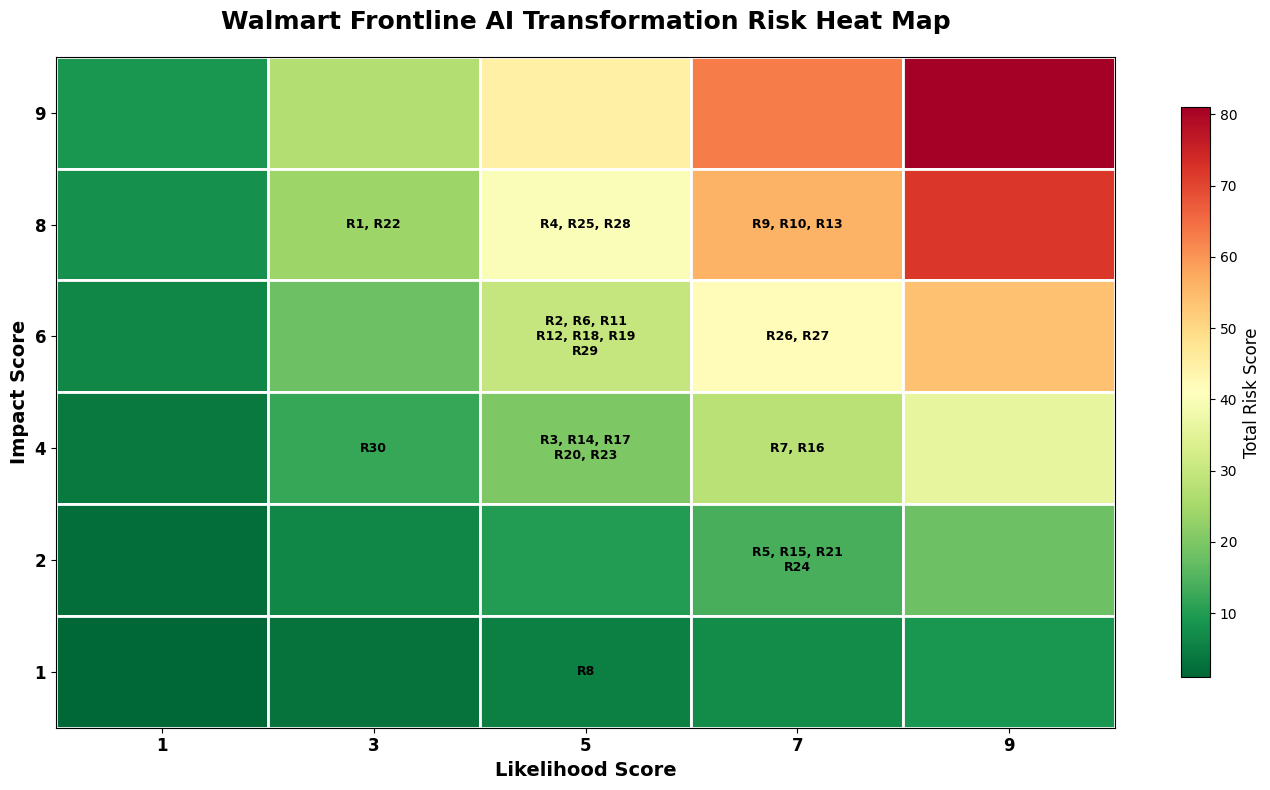

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

likelihood_values = [1,3,5,7,9]
impact_values = [9,8,6,4,2,1]

# Risk Score Matrix
score_matrix = np.array([
    [l*i for l in likelihood_values]
    for i in impact_values
])

fig, ax = plt.subplots(figsize=(14,8))

cmap = get_cmap("RdYlGn_r")
norm = Normalize(vmin=1, vmax=81)

# Draw cells
for i, impact in enumerate(impact_values):
    for j, likelihood in enumerate(likelihood_values):

        score = likelihood * impact

        rect = plt.Rectangle(
            (j, i),
            1,
            1,
            facecolor=cmap(norm(score)),
            edgecolor="white",
            linewidth=2
        )

        ax.add_patch(rect)

        risks = df[
            (df["Likelihood"] == likelihood) &
            (df["Impact"] == impact)
        ]["Risk ID"].tolist()

        if len(risks) > 0:

            label = "\n".join([
                ", ".join(risks[k:k+3])
                for k in range(0,len(risks),3)
            ])

            ax.text(
                j+0.5,
                i+0.5,
                label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

# Axis formatting
ax.set_xlim(0,5)
ax.set_ylim(0,6)

ax.set_xticks(np.arange(5)+0.5)
ax.set_xticklabels(
    likelihood_values,
    fontsize=12,
    fontweight="bold"
)

ax.set_yticks(np.arange(6)+0.5)
ax.set_yticklabels(
    impact_values,
    fontsize=12,
    fontweight="bold"
)

ax.invert_yaxis()

ax.set_xlabel(
    "Likelihood Score",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Impact Score",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Walmart Frontline AI Transformation Risk Heat Map",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Add color bar
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    shrink=0.85
)

cbar.set_label(
    "Total Risk Score",
    fontsize=12
)

plt.tight_layout()

plt.show()

Risk score ranking

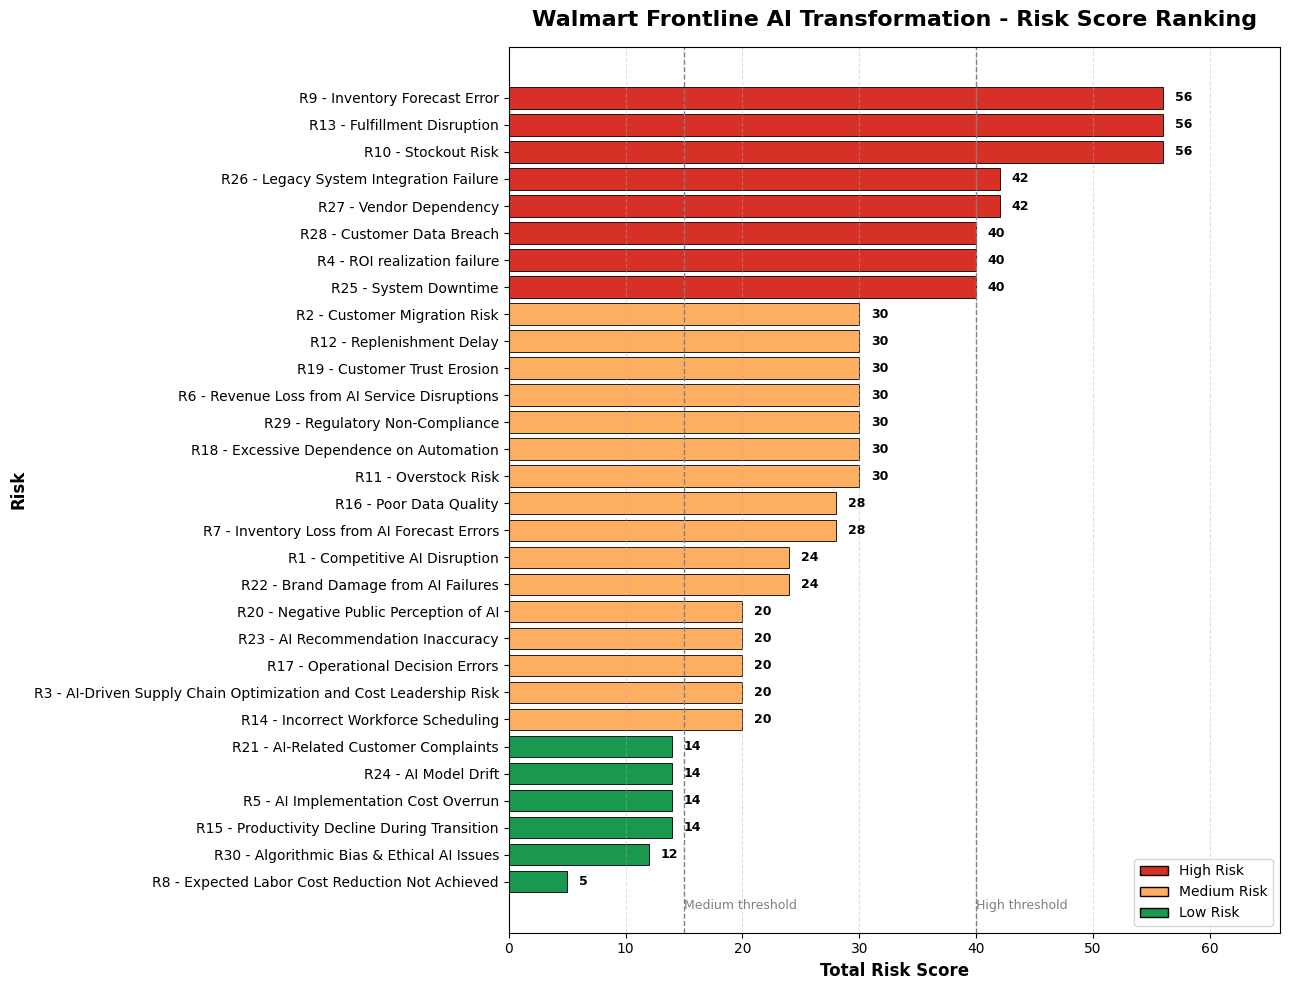

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Sort risks by score
df_ranked = df.sort_values("Risk Score", ascending=True).copy()

# Create label
df_ranked["Risk Label"] = df_ranked["Risk ID"] + " - " + df_ranked["Risk Name"]

# Assign colors by priority
priority_colors = {
    "H": "#d73027",   # red
    "M": "#fdae61",   # orange/yellow
    "L": "#1a9850"    # green
}

colors = df_ranked["Priority"].map(priority_colors)

plt.figure(figsize=(13, 10))

bars = plt.barh(
    df_ranked["Risk Label"],
    df_ranked["Risk Score"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# Add score labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# Add threshold lines
plt.axvline(15, color="gray", linestyle="--", linewidth=1)
plt.axvline(40, color="gray", linestyle="--", linewidth=1)

plt.text(15, -1, "Medium threshold", fontsize=9, color="gray")
plt.text(40, -1, "High threshold", fontsize=9, color="gray")

plt.xlabel("Total Risk Score", fontsize=12, fontweight="bold")
plt.ylabel("Risk", fontsize=12, fontweight="bold")
plt.title(
    "Walmart Frontline AI Transformation - Risk Score Ranking",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlim(0, max(df_ranked["Risk Score"]) + 10)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#d73027", edgecolor="black", label="High Risk"),
    Patch(facecolor="#fdae61", edgecolor="black", label="Medium Risk"),
    Patch(facecolor="#1a9850", edgecolor="black", label="Low Risk")
]

plt.legend(handles=legend_elements, loc="lower right")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Risk count matrix code

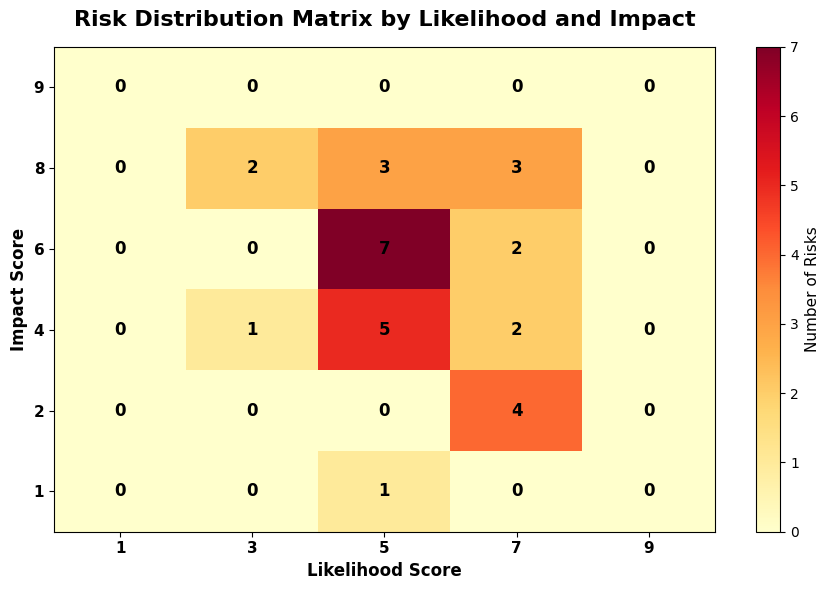

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

likelihood_values = [1, 3, 5, 7, 9]
impact_values = [9, 8, 6, 4, 2, 1]

count_matrix = pd.DataFrame(
    0,
    index=impact_values,
    columns=likelihood_values
)

for _, row in df.iterrows():
    count_matrix.loc[row["Impact"], row["Likelihood"]] += 1

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    count_matrix.values,
    cmap="YlOrRd",
    aspect="auto"
)

# Add text labels
for i in range(len(impact_values)):
    for j in range(len(likelihood_values)):
        value = count_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

ax.set_xticks(np.arange(len(likelihood_values)))
ax.set_xticklabels(likelihood_values, fontsize=11, fontweight="bold")

ax.set_yticks(np.arange(len(impact_values)))
ax.set_yticklabels(impact_values, fontsize=11, fontweight="bold")

ax.set_xlabel("Likelihood Score", fontsize=12, fontweight="bold")
ax.set_ylabel("Impact Score", fontsize=12, fontweight="bold")

ax.set_title(
    "Risk Distribution Matrix by Likelihood and Impact",
    fontsize=16,
    fontweight="bold",
    pad=15
)

cbar = plt.colorbar(im)
cbar.set_label("Number of Risks", fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
import matplotlib.patches as mpatches

# ==========================
# Updated M4 Risk Register Scores
# ==========================

data = {
    "Risk ID": [
        "R1","R2","R3","R4","R5","R6",
        "R7","R8","R9","R10","R11","R12",
        "R13","R14","R15","R16","R17","R18"
    ],
    "Risk Title": [
        "Competitive AI Disruption and Brand Damage from AI Failures",
        "Customer Migration Risk and Customer Trust Erosion",
        "AI-Driven Supply Chain Optimization and Cost Leadership Opportunity",
        "ROI Realization Failure from AI Transformation Investment",
        "Inventory Forecast Error, Stockout Risk and Fulfillment Disruption",
        "Legacy System Integration Failure and Vendor Dependency",
        "Customer Data Breach and Information Security Risk",
        "System Downtime and AI Platform Unavailability",
        "Revenue Loss from AI Service Disruptions",
        "Inventory Imbalance — Overstock and Replenishment Delay",
        "Inventory Loss from AI Forecast Errors",
        "Data Quality Failures and AI Recommendation Inaccuracy",
        "Excessive Dependence on Automation",
        "Regulatory Non-Compliance, Shadow AI and AI Governance Risk",
        "Workforce Scheduling and Operational Decision Errors",
        "Negative Public Perception and Algorithmic Bias Risk",
        "AI Transition Operational Inefficiencies",
        "Expected Labor Cost Reduction Not Achieved"
    ],
    "Likelihood": [
        3,5,5,5,7,9,
        5,7,5,5,7,7,
        5,7,5,5,7,5
    ],
    "Impact": [
        8,6,4,8,9,9,
        9,9,6,6,4,4,
        6,6,4,6,2,1
    ]
}

df = pd.DataFrame(data)
df["Risk Score"] = df["Likelihood"] * df["Impact"]

df

,Risk ID,Risk Title,Likelihood,Impact,Risk Score
0,R1,Competitive AI Disruption and Brand Damage fro...,3,8,24
1,R2,Customer Migration Risk and Customer Trust Ero...,5,6,30
2,R3,AI-Driven Supply Chain Optimization and Cost L...,5,4,20
3,R4,ROI Realization Failure from AI Transformation...,5,8,40
4,R5,"Inventory Forecast Error, Stockout Risk and Fu...",7,9,63
5,R6,Legacy System Integration Failure and Vendor D...,9,9,81
6,R7,Customer Data Breach and Information Security ...,5,9,45
7,R8,System Downtime and AI Platform Unavailability,7,9,63
8,R9,Revenue Loss from AI Service Disruptions,5,6,30
9,R10,Inventory Imbalance — Overstock and Replenishm...,5,6,30


C:\Users\user\AppData\Local\Temp\ipykernel_25788\2889350128.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("RdYlGn_r")


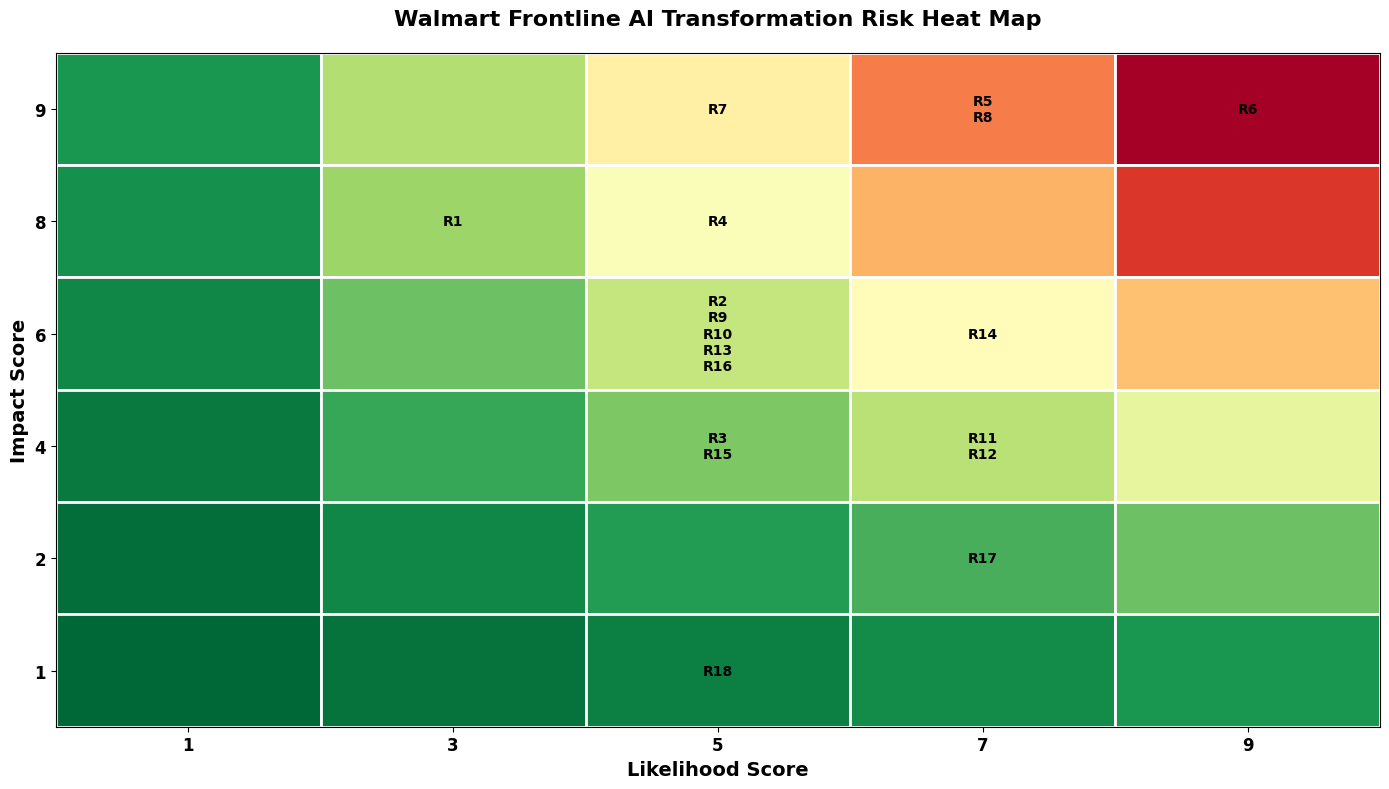

In [9]:
# ==========================
# Risk Heat Map
# ==========================

likelihood_values = [1, 3, 5, 7, 9]
impact_values = [9, 8, 6, 4, 2, 1]

fig, ax = plt.subplots(figsize=(14, 8))

cmap = get_cmap("RdYlGn_r")
norm = Normalize(vmin=1, vmax=81)

for i, impact in enumerate(impact_values):
    for j, likelihood in enumerate(likelihood_values):
        score = likelihood * impact

        rect = plt.Rectangle(
            (j, i),
            1,
            1,
            facecolor=cmap(norm(score)),
            edgecolor="white",
            linewidth=2
        )
        ax.add_patch(rect)

        risks = df[
            (df["Likelihood"] == likelihood) &
            (df["Impact"] == impact)
        ]["Risk ID"].tolist()

        if risks:
            ax.text(
                j + 0.5,
                i + 0.5,
                "\n".join(risks),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="black"
            )

ax.set_xlim(0, len(likelihood_values))
ax.set_ylim(0, len(impact_values))

ax.set_xticks(np.arange(len(likelihood_values)) + 0.5)
ax.set_xticklabels(likelihood_values, fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(impact_values)) + 0.5)
ax.set_yticklabels(impact_values, fontsize=12, fontweight="bold")

ax.invert_yaxis()

ax.set_xlabel("Likelihood Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Impact Score", fontsize=14, fontweight="bold")

ax.set_title(
    "Walmart Frontline AI Transformation Risk Heat Map",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

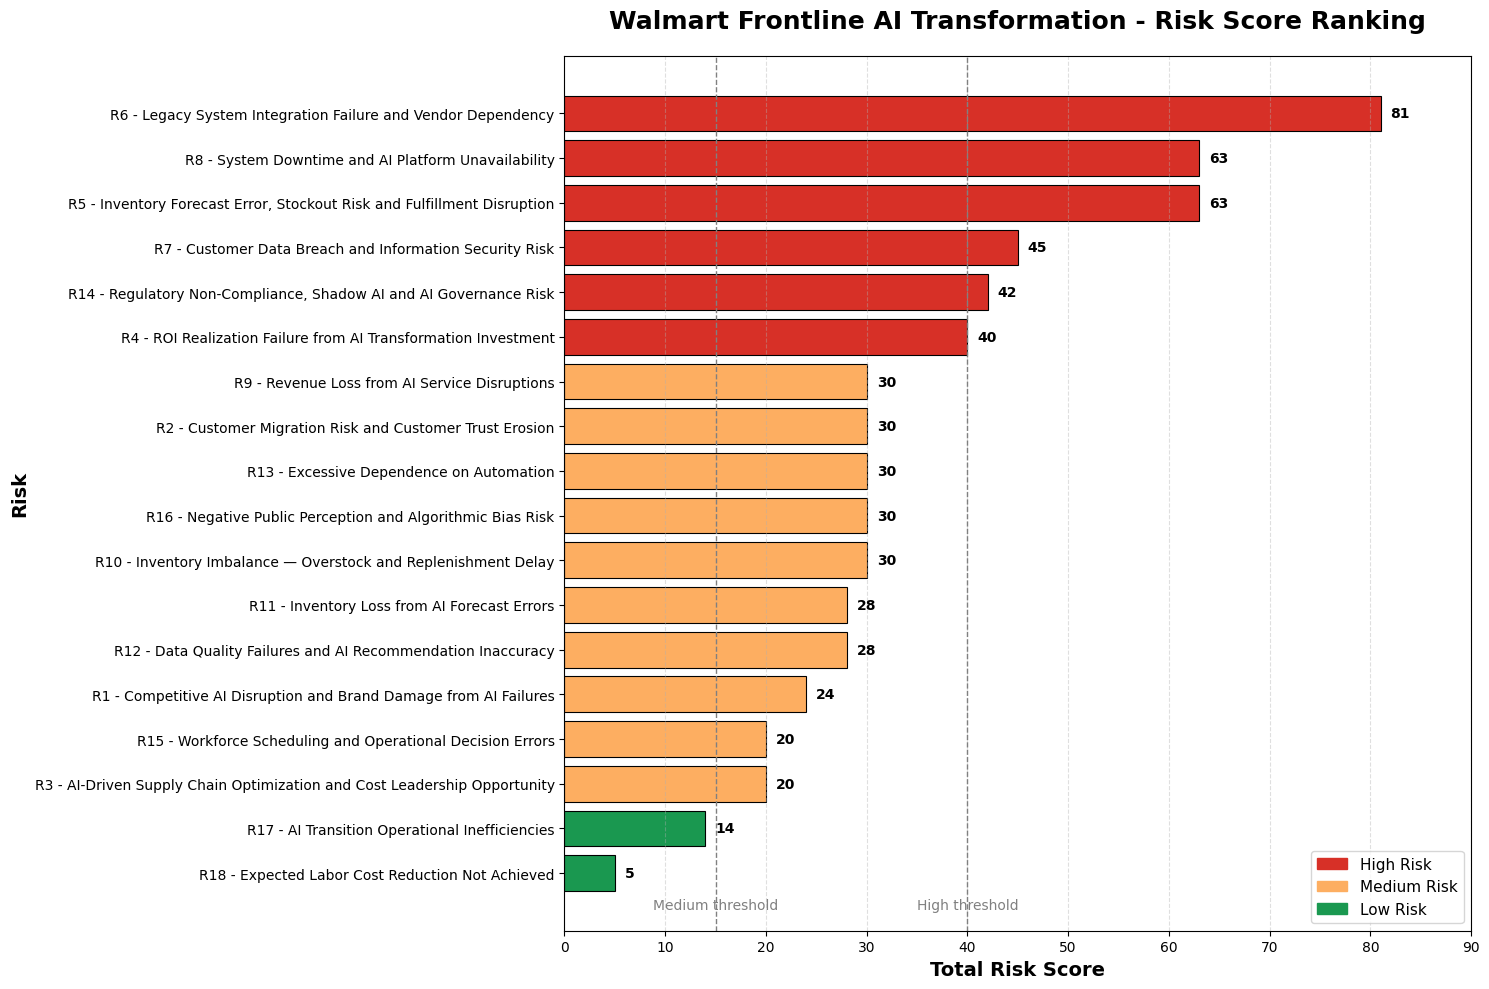

In [10]:
# ==========================
# Risk Score Ranking
# ==========================

def classify_risk(score):
    if score >= 40:
        return "High Risk"
    elif score >= 15:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk Level"] = df["Risk Score"].apply(classify_risk)

color_map = {
    "High Risk": "#d73027",
    "Medium Risk": "#fdae61",
    "Low Risk": "#1a9850"
}

df["Color"] = df["Risk Level"].map(color_map)
df["Label"] = df["Risk ID"] + " - " + df["Risk Title"]

df_ranked = df.sort_values("Risk Score", ascending=True)

fig, ax = plt.subplots(figsize=(15, 10))

bars = ax.barh(
    df_ranked["Label"],
    df_ranked["Risk Score"],
    color=df_ranked["Color"],
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.axvline(15, color="gray", linestyle="--", linewidth=1)
ax.axvline(40, color="gray", linestyle="--", linewidth=1)

ax.text(15, -0.8, "Medium threshold", ha="center", fontsize=10, color="gray")
ax.text(40, -0.8, "High threshold", ha="center", fontsize=10, color="gray")

ax.set_xlabel("Total Risk Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Risk", fontsize=14, fontweight="bold")

ax.set_title(
    "Walmart Frontline AI Transformation - Risk Score Ranking",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.grid(axis="x", linestyle="--", alpha=0.4)

legend_items = [
    mpatches.Patch(color=color_map["High Risk"], label="High Risk"),
    mpatches.Patch(color=color_map["Medium Risk"], label="Medium Risk"),
    mpatches.Patch(color=color_map["Low Risk"], label="Low Risk")
]

ax.legend(handles=legend_items, loc="lower right", fontsize=11, frameon=True)
ax.set_xlim(0, 90)

plt.tight_layout()
plt.show()

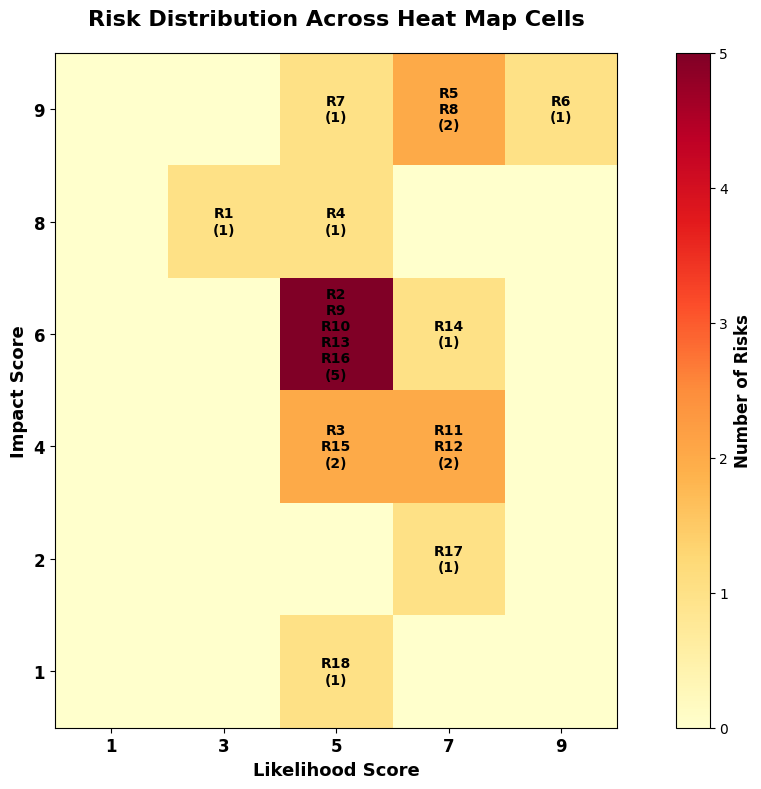

In [11]:
# ==========================
# Risk Distribution Heat Map
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

risk_data = {
    "Risk ID": [
        "R1","R2","R3","R4","R5","R6",
        "R7","R8","R9","R10","R11","R12",
        "R13","R14","R15","R16","R17","R18"
    ],

    "Likelihood":[
        3,5,5,5,7,9,
        5,7,5,5,7,7,
        5,7,5,5,7,5
    ],

    "Impact":[
        8,6,4,8,9,9,
        9,9,6,6,4,4,
        6,6,4,6,2,1
    ]
}

df = pd.DataFrame(risk_data)

likelihood_values = [1,3,5,7,9]
impact_values = [9,8,6,4,2,1]

count_matrix = pd.DataFrame(
    0,
    index=impact_values,
    columns=likelihood_values
)

label_matrix = pd.DataFrame(
    "",
    index=impact_values,
    columns=likelihood_values
)

for _, row in df.iterrows():

    impact = row["Impact"]
    likelihood = row["Likelihood"]
    risk_id = row["Risk ID"]

    count_matrix.loc[impact, likelihood] += 1

    if label_matrix.loc[impact, likelihood] == "":
        label_matrix.loc[impact, likelihood] = risk_id
    else:
        label_matrix.loc[impact, likelihood] += "\n" + risk_id

fig, ax = plt.subplots(figsize=(12,8))

im = ax.imshow(
    count_matrix,
    cmap="YlOrRd"
)

for i in range(len(impact_values)):
    for j in range(len(likelihood_values)):

        label = label_matrix.iloc[i,j]
        count = count_matrix.iloc[i,j]

        if count > 0:
            display_text = f"{label}\n({count})"
        else:
            display_text = ""

        ax.text(
            j,
            i,
            display_text,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(np.arange(len(likelihood_values)))
ax.set_xticklabels(
    likelihood_values,
    fontsize=12,
    fontweight="bold"
)

ax.set_yticks(np.arange(len(impact_values)))
ax.set_yticklabels(
    impact_values,
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Likelihood Score",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Impact Score",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "Risk Distribution Across Heat Map Cells",
    fontsize=16,
    fontweight="bold",
    pad=20
)

cbar = plt.colorbar(im)
cbar.set_label(
    "Number of Risks",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()